In [9]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

In [15]:
df = pd.read_csv('../../data/csv/BMI.csv')
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)
df

['NCD_BMI_18A', 'NCD_BMI_18C', 'NCD_BMI_25A', 'NCD_BMI_25C', 'NCD_BMI_30A', 'NCD_BMI_30C', 'NCD_BMI_MEAN', 'NCD_BMI_MEANC', 'NCD_BMI_MINUS2C', 'NCD_BMI_PLUS1C', 'NCD_BMI_PLUS2C']


,Unnamed: 0,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim,IndicatorCode
0,0,AFR,GHA,8.5 [7.4-9.5],8.456378,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012,YEAR,2012,NCD_BMI_18A
1,1,AMR,ECU,1.6 [1.3-2.0],1.631755,2013-01-01T00:00:00+01:00,2013-12-31T00:00:00+01:00,2013,YEAR,2013,NCD_BMI_18A
2,2,AMR,CRI,3.2 [2.2-4.5],3.172688,2003-01-01T00:00:00+01:00,2003-12-31T00:00:00+01:00,2003,YEAR,2003,NCD_BMI_18A
3,3,AFR,GIN,10.1 [6.6-14.4],10.132378,2022-01-01T00:00:00+01:00,2022-12-31T00:00:00+01:00,2022,YEAR,2022,NCD_BMI_18A
4,4,EMR,SAU,3.9 [3.1-4.9],3.914519,2014-01-01T00:00:00+01:00,2014-12-31T00:00:00+01:00,2014,YEAR,2014,NCD_BMI_18A
...,...,...,...,...,...,...,...,...,...,...,...
453072,453072,EUR,BEL,5.1 [3.4-7.0],5.051485,1997-01-01T00:00:00+01:00,1997-12-31T00:00:00+01:00,1997,YEAR,1997,NCD_BMI_PLUS2C
453073,453073,EMR,SDN,1.7 [0.7-3.4],1.715090,2006-01-01T00:00:00+01:00,2006-12-31T00:00:00+01:00,2006,YEAR,2006,NCD_BMI_PLUS2C
453074,453074,AFR,CPV,1.8 [0.4-5.0],1.842421,2000-01-01T00:00:00+01:00,2000-12-31T00:00:00+01:00,2000,YEAR,2000,NCD_BMI_PLUS2C
453075,453075,AFR,STP,4.7 [0.9-12.3],4.681022,2005-01-01T00:00:00+01:00,2005-12-31T00:00:00+01:00,2005,YEAR,2005,NCD_BMI_PLUS2C


In [16]:
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

453077
449717
0


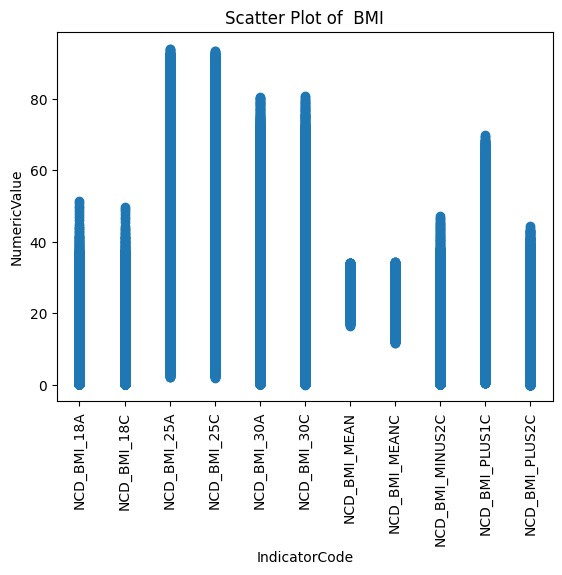

In [25]:
plt.figure()
plt.scatter(df['IndicatorCode'], df['NumericValue'])
plt.xlabel('IndicatorCode')
plt.ylabel('NumericValue')
plt.title('Scatter Plot of  BMI')
plt.xticks(rotation=90)
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_8360\1515023557.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


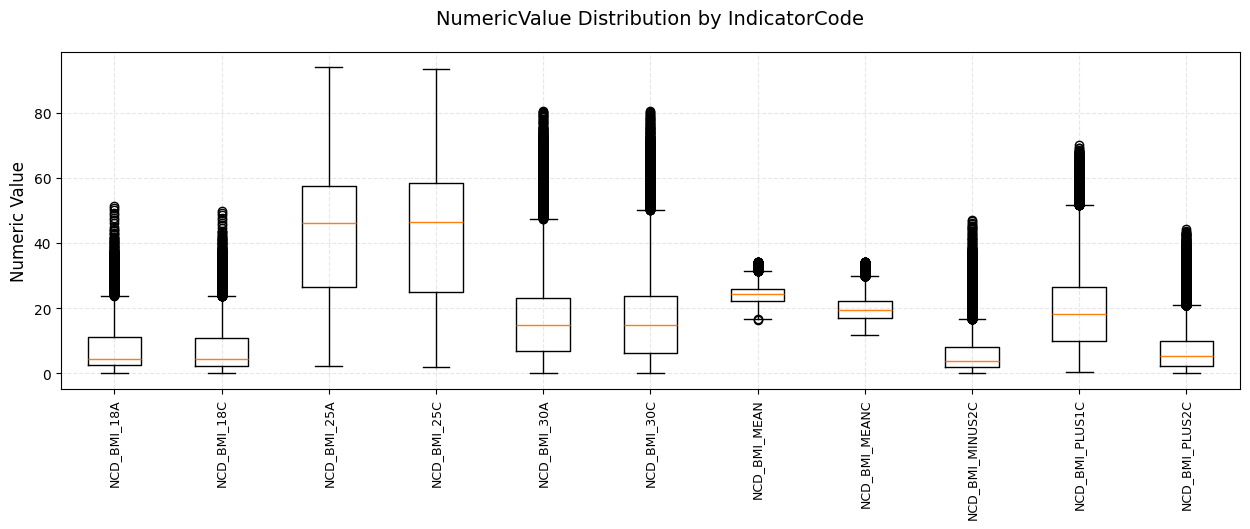

In [19]:
plt.figure(figsize=(14, 6))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
plt.xticks(rotation=90, fontsize=9)  # Xoay 90 độ và giảm font
plt.title('NumericValue Distribution by IndicatorCode', fontsize=14, pad=20)
plt.ylabel('Numeric Value', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Điều chỉnh layout để nhãn không bị cắt
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_8360\799527188.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")
C:\Users\USER\AppData\Local\Temp\ipykernel_8360\799527188.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Date"] = pd.to_datetime(df1["TimeDimensionBegin"], errors="coerce", utc=True)


Số lượng bản ghi BMI: 20790
Khoảng thời gian: 1989-12-31 23:00:00+00:00 đến 2021-12-31 23:00:00+00:00
Số quốc gia: 210

Thống kê MeanValue:
count    199.000000
mean       7.256240
std        6.634012
min        0.368045
25%        2.525298
50%        4.040328
75%       11.475751
max       33.618317
Name: MeanValue, dtype: float64

Số quốc gia có dữ liệu sau khi gộp: 199

Các cột trong bản đồ: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', '

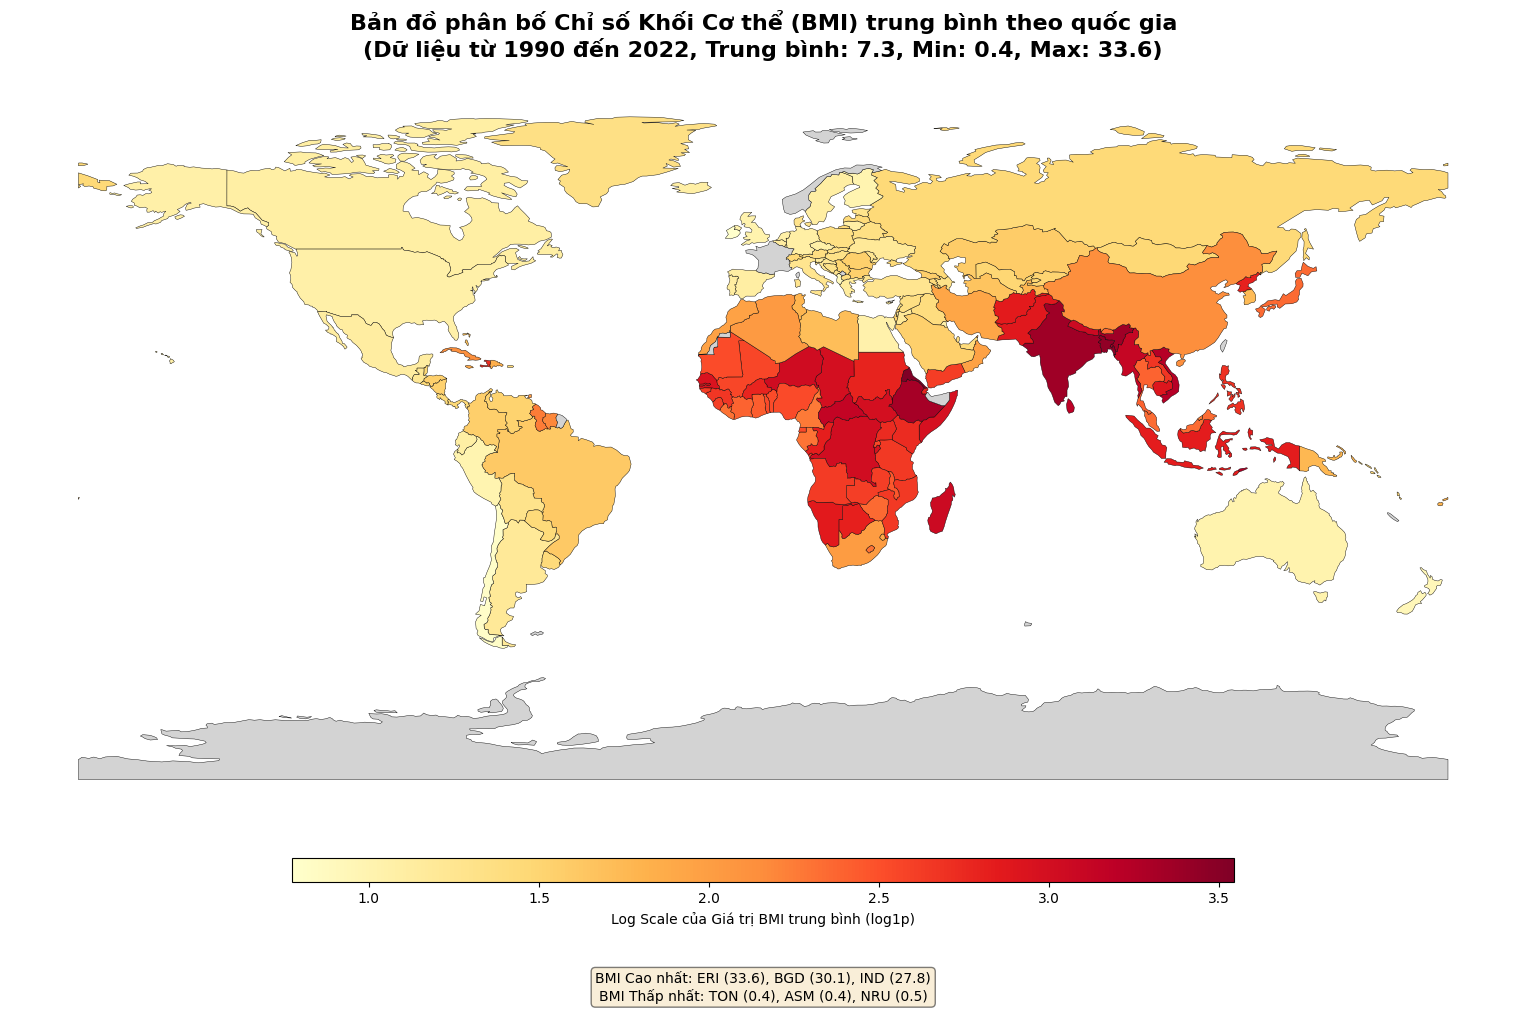

In [23]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# ==============================
# 1. KIỂM TRA & CHUẨN HÓA DỮ LIỆU BMI
# ==============================
# Lọc dữ liệu cho chỉ số BMI (dữ liệu của bạn là NCD_BMI_18A)
df1 = df[df['IndicatorCode'] == 'NCD_BMI_18A']

# Chuyển đổi giá trị số
df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")

# Xử lý cột thời gian - dữ liệu của bạn có TimeDimensionBegin
# Chuyển đổi thành datetime với UTC
df1["Date"] = pd.to_datetime(df1["TimeDimensionBegin"], errors="coerce", utc=True)

# Kiểm tra dữ liệu
print(f"Số lượng bản ghi BMI: {len(df1)}")
print(f"Khoảng thời gian: {df1['Date'].min()} đến {df1['Date'].max()}")
print(f"Số quốc gia: {df1['SpatialDim'].nunique()}")

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
# Nhóm dữ liệu theo quốc gia và tính trung bình
df_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count"),
        # Có thể thêm các thống kê khác nếu cần
        MinValue=("NumericValue", "min"),
        MaxValue=("NumericValue", "max"),
        StdValue=("NumericValue", "std")
    )
)

# Kiểm tra phân bố dữ liệu
print("\nThống kê MeanValue:")
print(df_grouped["MeanValue"].describe())

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

print(f"\nSố quốc gia có dữ liệu sau khi gộp: {len(df_grouped)}")

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
# Lưu ý: Đảm bảo file bản đồ đúng đường dẫn
world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")

# Kiểm tra cột mã quốc gia trong bản đồ
print("\nCác cột trong bản đồ:", world.columns.tolist())

# Merge dữ liệu BMI với bản đồ
# SpatialDim trong dữ liệu của bạn là mã quốc gia 3 ký tự (ISO_A3)
gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",  # Đảm bảo đúng tên cột trong shapefile
    right_on="SpatialDim"
)

# Kiểm tra kết quả merge
print(f"Số quốc gia trong bản đồ: {len(world)}")
print(f"Số quốc gia sau merge: {len(gdf)}")
print(f"Số quốc gia có dữ liệu BMI: {gdf['MeanValue'].notna().sum()}")

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 10))

# Tạo colormap - chọn màu phù hợp cho BMI
# Viridis, Plasma, YlOrRd, RdYlBu_r đều là lựa chọn tốt
cmap = plt.cm.YlOrRd  # Hoặc "viridis", "plasma"

# Vẽ bản đồ với màu sắc dựa trên LogMeanValue
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Giá trị BMI trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05,
        'shrink': 0.6,
        'aspect': 40
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Không có dữ liệu",
        "edgecolor": "black",
        "linewidth": 0.3
    }
)

# Thêm thông tin thống kê vào title
avg_bmi = df_grouped["MeanValue"].mean()
min_bmi = df_grouped["MeanValue"].min()
max_bmi = df_grouped["MeanValue"].max()

title = (
    f"Bản đồ phân bố Chỉ số Khối Cơ thể (BMI) trung bình theo quốc gia\n"
    f"(Dữ liệu từ {df1['TimeDimensionValue'].min()} đến {df1['TimeDimensionValue'].max()}, "
    f"Trung bình: {avg_bmi:.1f}, Min: {min_bmi:.1f}, Max: {max_bmi:.1f})"
)

ax.set_title(title, fontsize=16, pad=20, fontweight='bold')

# Thêm annotation cho các quốc gia có giá trị cao/thấp nhất
# Tìm 3 quốc gia có BMI cao nhất và thấp nhất
top_3 = df_grouped.nlargest(3, 'MeanValue')
bottom_3 = df_grouped.nsmallest(3, 'MeanValue')

# Thêm text thông tin
info_text = (
    f"BMI Cao nhất: {top_3.iloc[0]['SpatialDim']} ({top_3.iloc[0]['MeanValue']:.1f}), "
    f"{top_3.iloc[1]['SpatialDim']} ({top_3.iloc[1]['MeanValue']:.1f}), "
    f"{top_3.iloc[2]['SpatialDim']} ({top_3.iloc[2]['MeanValue']:.1f})\n"
    f"BMI Thấp nhất: {bottom_3.iloc[0]['SpatialDim']} ({bottom_3.iloc[0]['MeanValue']:.1f}), "
    f"{bottom_3.iloc[1]['SpatialDim']} ({bottom_3.iloc[1]['MeanValue']:.1f}), "
    f"{bottom_3.iloc[2]['SpatialDim']} ({bottom_3.iloc[2]['MeanValue']:.1f})"
)

plt.figtext(0.5, 0.01, info_text, ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.axis("off")
plt.tight_layout()
plt.show()

